# ml_7 : `ml_4` + `ratio_PAY_BILL_regularite` et `TYPE_USAGE`

**But** : mesurer, sur les clients laissés au machine learning, ce que les **6 modèles d'origine** obtiennent avec l'ajout des colonnes `ratio_PAY_BILL_regularite` et `TYPE_USAGE` au scénario retenu `ml_4` (taux de remboursement global et vie du compte), comparé à `ml_4.ipynb`


**Données** : `data/ML/train_dataset.csv`, produit par `creation_datasets_ML.ipynb` (périmètre S12, clients au contentieux à M retirés, 80 % des clients restants). **Le jeu de test n'est pas lu** : il est réservé à l'évaluation finale, lue une seule fois à la toute fin du machine learning, une fois tous les scénarios faits et le modèle final figé (jamais dans un notebook de scénario).

**Après un clone du dépôt** : les fichiers produits par les lancements (train et test, probabilités hors pli, fichier de résultats, modèles) ne sont pas dans le dépôt. Les sorties ci-dessous se lisent telles quelles ; pour relancer ce notebook, exécuter d'abord `creation_datasets_ML.ipynb`, puis les scénarios précédents dans l'ordre (section 0 de `methodologie_ML.md`).

**Méthode** (identique pour tous les scénarios, détaillée dans `methodologie_ML.md`) :
- validation croisée stratifiée à 5 plis, `random_state=42`, sur le train uniquement ;
- **objectif de détection** : le modèle doit trouver une part fixée des défauts, le **rappel minimal** (`RAPPEL_MINIMAL` : 60 % pour commencer, objectif 70 %). C'est un choix de départ, pas un réglage optimisé sur la cible ;
- **la boucle optimise la précision des défauts prédits** (part des clients prédits en défaut qui font réellement défaut), au taux de rappel minimal : sur chaque pli de validation, le seuil est placé là où le modèle détecte cette part des défauts, puis on mesure la part des clients signalés qui sont réellement en défaut. Le seuil n'est pas optimisé : il découle du rappel minimal. Tous les modèles sont ainsi jugés au même rappel, quel que soit le niveau de leurs probabilités ;
- le score est donné avec son **écart-type sur les 5 plis** : un écart entre deux modèles plus petit que cet écart-type n'est pas une différence, c'est du bruit ;
- en contrôle : le **ROC AUC** (qualité du tri des clients, sans seuil) et la **précision moyenne** (précision moyenne sur tous les rappels) ;
- défauts détectés et précision mesurés en validation (chaque client est prédit par un modèle qui ne l'a pas vu).

**Étapes** :
1. chargement du train et choix des variables ;
2. premier essai des 6 modèles, avec leurs réglages par défaut ;
3. recherche des hyperparamètres par une boucle automatique de GridSearch : choix de la meilleure précision sous contrainte de surapprentissage, grille corrigée tour après tour (paramètres au bord, surapprentissage) ;
4. matrices de confusion au seuil du rappel minimal, précision à plusieurs rappels, importance des variables, en validation ; enregistrement des probabilités hors pli (toute autre métrique reste calculable sans relancer les modèles) ;
5. podium détaillé et enregistrement du meilleur modèle.

In [1]:
# ==============================================================================
# RÉGLAGES DU LANCEMENT : avec la cellule « variables du scénario », la seule cellule à modifier
# ==============================================================================

# Numéro du scénario : nomme le notebook (ml_<numéro>), le modèle enregistré et le fichier des probabilités hors pli
numero_scenario = "7"

# Ce qui change dans ce scénario, en une phrase : recopiée dans la ligne du journal (tableau_ML.md)
ce_qui_change = "ml_4 + ajout des colonnes `ratio_PAY_BILL_regularite` et `TYPE_USAGE` ; 6 modèles"

# Scénario de référence, choisi à la main : le scénario RETENU auquel se comparer (section 7).
# Pas forcément le précédent : un scénario testé puis écarté ne sert pas de référence. None pour le socle (ml_0).
# Pour comparer à d'autres scénarios (fusion de deux scénarios, contrôle par rapport au socle…) : section 8, « Comparaisons libres »
scenario_reference = "4"

# Version de la méthode : à changer seulement quand la MÉTHODE change (score, boucle, seuils…), jamais d'un scénario à l'autre.
# Elle date les résultats et les probabilités enregistrés ; deux scénarios ne se comparent qu'avec la même version.
# Liste des versions : methodologie_ML.md, section 11
VERSION_METHODE = "v8"


## 1. Chargement et variables

Le train est lu, puis la cellule **« variables du scénario »** fixe les colonnes données aux modèles. C'est la seule cellule à modifier pour changer de variables d'un scénario à l'autre.

**Le socle** : les 23 variables d'origine, c'est-à-dire le plafond (`LIMIT_BAL`), la démographie (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`), les codifications de paiement (`PAY_1` à `PAY_6`, corrigées au niveau 5 du nettoyage, traitées comme des nombres : voir l'encodage plus bas), les factures (`BILL_AMT1` à `BILL_AMT6`) et les paiements (`PAY_AMT1` à `PAY_AMT6`). L'identifiant `ID` et la cible `dpnm` ne sont jamais des variables.

**Ajouter une colonne** (elle doit être définie dans `docs/colonnes_creees.md` et présente dans le train) : la ranger dans la liste qui correspond à son encodage :
- `ajout_num` : nombres, montants, ratios, compteurs ;
- `ajout_log` : montants positifs ou nuls très étirés (quelques valeurs énormes, la plupart petites), passés au logarithme avant la mise à l'échelle, comme les paiements du socle ;
- `ajout_log_signe` : montants qui peuvent être négatifs (avoirs), passés au logarithme signé avant la mise à l'échelle, comme les factures du socle ;
- `ajout_cat` : catégories sans ordre (une colonne par catégorie), par exemple un type d'usage, et les indicateurs 0 / 1 (comme `SEX` dans le socle) ;
- `ajout_ord` : catégories dans un ordre naturel qui ne sont pas des nombres (encodage ordinal), par exemple des tranches nommées. Une variable déjà numérique et ordonnée (une codification, un nombre de mois) va dans `ajout_num`.

**Remplacer une valeur** (un -1, un vide, une catégorie) : la décision prise dans `docs/colonnes_creees.md` (colonne « Adaptation et usage ML ») s'écrit dans `remplacements`, sous la forme `colonne: (valeurs remplacées, valeur)`. La valeur est **précise, décidée par le métier**, jamais calculée sur les clients (ni médiane ni moyenne). Le remplacement ne s'applique que si la colonne est une variable du scénario, quelle que soit sa liste. Les décisions déjà prises y sont écrites ; une colonne qui garde des vides sans remplacement décidé arrête le notebook.

**Retirer une colonne du socle** (variante sans codifications, par exemple) : l'écrire dans `retirees`.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# Racine du projet : premier dossier parent qui contient 'data'
current_dir = Path.cwd()
root_dir = next(p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists())

train = pd.read_csv(root_dir / "data" / "ML" / "train_dataset.csv")
print(f"Clients du train : {len(train)} ; colonnes disponibles : {train.shape[1]}")

Clients du train : 19358 ; colonnes disponibles : 52


In [3]:
# ==============================================================================
# VARIABLES DU SCÉNARIO : seule cellule à modifier pour changer les colonnes
# ==============================================================================

# Colonnes ajoutées par ce scénario, rangées selon leur encodage
ajout_num = ["ratio_PAY_BILL_global", "ratio_PAY_BILL_regularite"]   # nombres, montants, ratios, compteurs
ajout_log = []   # montants positifs ou nuls très étirés : logarithme, puis mise à l'échelle
ajout_log_signe = []   # montants qui peuvent être négatifs (avoirs) : logarithme signé, puis mise à l'échelle
ajout_cat = ["FLAG_OUVERTURE", "FLAG_DEGEL", "MOIS_ACTIVATION", "TYPE_USAGE"]   # catégories sans ordre (une colonne par catégorie), indicateurs 0 / 1
ajout_ord = []   # catégories dans un ordre naturel (encodage ordinal)

# Colonnes du socle retirées par ce scénario
retirees = []

# ------------------------------------------------------------------------------
# Socle : les 23 variables d'origine (ne pas modifier)
# PAY_n : des nombres déjà ordonnés et régulièrement espacés (-2 à 8, un cran par mois de retard), mis à l'échelle comme les autres (v6)
# PAY_AMTn : paiements très étirés (médiane d'environ 2 000 NT$, maximum de plus de 400 000 NT$), passés au logarithme (v7)
# BILL_AMTn : factures, traitées comme les paiements qu'elles appellent, avec un logarithme signé (avoirs négatifs) (v8)
socle_num = ["LIMIT_BAL", "AGE"] + [f"PAY_{n}" for n in range(1, 7)]
socle_log = [f"PAY_AMT{n}" for n in range(1, 7)]
socle_log_signe = [f"BILL_AMT{n}" for n in range(1, 7)]
socle_cat = ["SEX", "EDUCATION", "MARRIAGE"]
socle_ord = []

# ------------------------------------------------------------------------------
# Remplacements décidés dans docs/colonnes_creees.md (colonne « Adaptation et usage ML ») : {colonne: (valeurs remplacées, valeur)}
# Faits dans le pipeline, avant la transformation propre au type de la colonne (mise à l'échelle, logarithme, catégories…),
# et donc enregistrés avec le modèle. Valeur précise décidée par le métier, jamais calculée sur les clients (ni médiane ni moyenne).
# Actifs seulement si la colonne est une variable du scénario, quelle que soit sa liste. Un vide s'écrit np.nan ; une catégorie
# s'écrit en texte. À compléter à chaque nouvelle décision
remplacements = {
    "ratio_PAY_BILL_global": ([np.nan], 100),          # dû nul ou négatif : rien à payer, client à jour
    "ratio_PAY_BILL_median": ([-1], 100),              # seule la facture de septembre est due
    "ratio_PAY_BILL_regularite": ([np.nan, -1], 100),  # une seule facture due, ou « Première facture »
}

num_col = [c for c in socle_num if c not in retirees] + ajout_num
log_col = [c for c in socle_log if c not in retirees] + ajout_log
log_signe_col = [c for c in socle_log_signe if c not in retirees] + ajout_log_signe
cat_col = [c for c in socle_cat if c not in retirees] + ajout_cat
ord_col = [c for c in socle_ord if c not in retirees] + ajout_ord
variables = num_col + log_col + log_signe_col + cat_col + ord_col

# Contrôles : colonnes présentes dans le train, aucune en double, ni identifiant ni cible
absentes = [c for c in variables + retirees if c not in train.columns]
doublons = sorted({c for c in variables if variables.count(c) > 1})
interdites = [c for c in variables if c in ("ID", "dpnm")]
assert not absentes, f"Colonnes absentes du train : {absentes} (à créer dans creation_datasets_ML.ipynb)"
assert not doublons, f"Colonnes en double : {doublons}"
assert not interdites, f"Colonnes interdites comme variables : {interdites}"
# Logarithme : montants positifs ou nuls, une fois les valeurs remplacées mises de côté
for c in log_col:
    valeurs = train[c].dropna()
    if c in remplacements:
        valeurs = valeurs[~valeurs.isin([v for v in remplacements[c][0] if not pd.isna(v)])]
    assert (valeurs >= 0).all(), f"Le logarithme ne s'applique qu'à des montants positifs ou nuls : {c}"
# Remplacements : aucune variable ne garde un vide sans remplacement décidé
remplacees = [c for c in variables if c in remplacements]
vides_sans_remplacement = [c for c in variables if train[c].isna().any()
                           and not (c in remplacements and any(pd.isna(v) for v in remplacements[c][0]))]
assert not vides_sans_remplacement, f"Colonnes avec des vides, sans remplacement décidé dans docs/colonnes_creees.md : {vides_sans_remplacement}"

X_train = train[variables].reset_index(drop=True)
y_train = train["dpnm"].reset_index(drop=True)

print(f"Variables        : {len(variables)} ({len(num_col)} numériques, {len(log_col)} au logarithme, {len(log_signe_col)} au logarithme signé, {len(cat_col)} catégorielles, {len(ord_col)} ordinales)")
print(f"Ajoutées         : {ajout_num + ajout_log + ajout_log_signe + ajout_cat + ajout_ord if ajout_num + ajout_log + ajout_log_signe + ajout_cat + ajout_ord else 'aucune'}")
print(f"Retirées         : {retirees if retirees else 'aucune'}")
print(f"Remplacements    : {', '.join(f'{c} ({remplacements[c][0]} -> {remplacements[c][1]})' for c in remplacees) if remplacees else 'aucun'}")
print(f"Défauts          : {y_train.sum()} ({y_train.mean() * 100:.2f} %)")

Variables        : 29 (10 numériques, 6 au logarithme, 6 au logarithme signé, 7 catégorielles, 0 ordinales)
Ajoutées         : ['ratio_PAY_BILL_global', 'ratio_PAY_BILL_regularite', 'FLAG_OUVERTURE', 'FLAG_DEGEL', 'MOIS_ACTIVATION', 'TYPE_USAGE']
Retirées         : aucune
Remplacements    : ratio_PAY_BILL_global ([nan] -> 100), ratio_PAY_BILL_regularite ([nan, -1] -> 100)
Défauts          : 3084 (15.93 %)


**Encodage** (dans le pipeline, donc appris sur chaque pli de la validation croisée, sans fuite) :
- variables numériques (`num_col` : plafond, âge, **codifications `PAY_1` à `PAY_6`** et colonnes de `ajout_num`) : centrées et réduites (`StandardScaler` : moyenne 0, écart-type 1, sans bornes ; l'ordre et les écarts entre valeurs sont gardés) ;
- **paiements** (`log_col` : `PAY_AMT1` à `PAY_AMT6` et colonnes de `ajout_log`) : **logarithme** (`log(1 + montant)`), puis centrés et réduits (v7). Les paiements sont très étirés : une médiane d'environ 2 000 NT$, mais quelques remboursements de plus de 400 000 NT$. Mis à l'échelle tels quels, 96 % des clients étaient tassés entre -1 et +1 ; le logarithme rapproche les très gros paiements et étale les petits et moyens, sans changer leur ordre. Sans effet attendu sur les arbres, qui ne dépendent que de l'ordre ;
- **factures** (`log_signe_col` : `BILL_AMT1` à `BILL_AMT6` et colonnes de `ajout_log_signe`) : **logarithme signé** (`arcsinh`, qui se comporte comme un logarithme pour les grandes valeurs et garde le signe des avoirs), puis centrées et réduites (v8). Le paiement du mois n règle la facture du mois n+1 : traitées de la même façon, les deux montants se comparent directement, et un modèle linéaire peut retrouver leur rapport (la différence de deux logarithmes est le logarithme du rapport) ;
- catégories sans ordre (`cat_col` : `SEX`, `EDUCATION`, `MARRIAGE` et colonnes de `ajout_cat`) : une colonne par catégorie (`OneHotEncoder`) ;
- catégories ordonnées qui ne sont pas des nombres (`ord_col` : colonnes de `ajout_ord`, aucune dans le socle) : encodage ordinal, puis centrées et réduites.
- **remplacements** (`remplacements`, cellule « variables du scénario ») : avant la transformation propre à son type, une colonne avec un remplacement décidé voit ses valeurs remplacées par une valeur fixe (`SimpleImputer`, valeur constante), dans sa propre branche du pipeline. Le remplacement est donc enregistré avec le modèle et appliqué de la même façon au test. Sans remplacement, comme dans le socle, le pipeline est exactement celui de la v8.

**Pourquoi les `PAY_n` sont traités comme des nombres (v6)** : leurs valeurs (-2 à 8) sont déjà ordonnées et régulièrement espacées. L'encodage ordinal utilisé jusqu'à la v5 les remplaçait par leur rang parmi les valeurs vues à l'entraînement de chaque pli : une valeur rare absente de l'entraînement (un retard de 6, 7 ou 8 mois, celui de clients sortis du contentieux) devenait « inconnue » et était placée **sous** les meilleurs payeurs. Mis à l'échelle comme des nombres, un retard de 8 mois reste le plus grand, vu ou non.

Le déséquilibre des classes (environ 1 client sur 6 en défaut) est compensé par une pondération des défauts pour les modèles qui l'acceptent (`class_weight='balanced'`, `scale_pos_weight` pour CatBoost). KNN et le réseau de neurones (MLP) n'ont pas cette option : ils sont gardés tels quels, comme dans la première itération.


In [4]:
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
import numpy as np
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# Pondération des défauts pour CatBoost (part des non-défauts / part des défauts)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

# Transformation de chaque type de colonne (un nouvel objet à chaque appel)
TRANSFORMATIONS = {
    "num": lambda: StandardScaler(),
    "log": lambda: make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler()),
    "log_signe": lambda: make_pipeline(FunctionTransformer(np.arcsinh, feature_names_out="one-to-one"), StandardScaler()),
    "nom": lambda: OneHotEncoder(sparse_output=False, handle_unknown="ignore"),
    "ord": lambda: make_pipeline(OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), StandardScaler()),
}
COLONNES_PAR_TYPE = {"num": num_col, "log": log_col, "log_signe": log_signe_col, "nom": cat_col, "ord": ord_col}

def avec_remplacement(colonne, transformation):
    # Valeurs remplacées par la valeur décidée (cellule « variables du scénario »), puis transformation propre au type
    valeurs, valeur = remplacements[colonne]
    # Le vide d'abord : SimpleImputer refuse une colonne qui contient des vides quand il cherche une autre valeur
    valeurs = sorted(valeurs, key=lambda v: not pd.isna(v))
    return make_pipeline(*[SimpleImputer(missing_values=v, strategy="constant", fill_value=valeur) for v in valeurs], transformation)

# Une branche par type pour les colonnes sans remplacement, une branche par colonne avec remplacement.
# Sans remplacement (le socle), le pipeline est exactement celui de la v8
preprocessor = ColumnTransformer(transformers=
    [(nom, TRANSFORMATIONS[nom](), [c for c in colonnes if c not in remplacements]) for nom, colonnes in COLONNES_PAR_TYPE.items()]
    + [(f"remplacement_{c}", avec_remplacement(c, TRANSFORMATIONS[nom]()), [c])
       for nom, colonnes in COLONNES_PAR_TYPE.items() for c in colonnes if c in remplacements])

# Objectif de détection : part des défauts que le modèle doit trouver (60 % pour commencer, objectif 70 %)
RAPPEL_MINIMAL = 0.60

def seuil_pour_rappel(y, proba, rappel=RAPPEL_MINIMAL):
    # Seuil le plus haut qui détecte au moins la part voulue des défauts
    proba_defauts = np.sort(proba[np.asarray(y) == 1])[::-1]
    return proba_defauts[int(np.ceil(rappel * len(proba_defauts))) - 1]

def score_decision(estimator, X, y):
    # Précision au seuil qui détecte au moins RAPPEL_MINIMAL des défauts (score optimisé par la boucle)
    proba = estimator.predict_proba(X)[:, 1]
    signales = proba >= seuil_pour_rappel(y, proba)
    return np.asarray(y)[signales].mean()

scorers = {
    "decision": score_decision,
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modèles lancés dans ce notebook : retirer un nom pour ne pas le lancer (le reste du notebook s'adapte)
MODELES_A_TESTER = ["LogisticRegression", "SVM", "MLPClassifier", "KNN", "RandomForest", "CatBoost"]

def modeles_de_base():
    # Les 6 modèles d'origine, avec leurs réglages de la première itération ; seuls ceux de MODELES_A_TESTER sont rendus
    tous = {
        "LogisticRegression": make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
        "SVM": make_pipeline(preprocessor, CalibratedClassifierCV(estimator=SVC(class_weight="balanced", random_state=42), ensemble=False)),
        "MLPClassifier": make_pipeline(preprocessor, MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42, early_stopping=True)),
        "KNN": make_pipeline(preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
        "RandomForest": make_pipeline(preprocessor, RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
        "CatBoost": make_pipeline(preprocessor, CatBoostClassifier(scale_pos_weight=scale_pos, random_state=42, verbose=0, thread_count=-1, allow_writing_files=False)),
    }
    return {nom: tous[nom] for nom in MODELES_A_TESTER}

In [5]:
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", None)   # textes affichés en entier

SEUIL_SURAPPRENTISSAGE = 0.05   # écart relatif train - val (écart / score de validation) au-delà duquel on alerte ; le double : surapprentissage fort
SEUIL_INSTABILITE = 0.02        # écart-type de la précision sur les plis au-delà duquel on alerte (alerte seule, pas une contrainte)
METRIQUES = {"decision": "Précision", "roc_auc": "ROC AUC", "average_precision": "Précision moyenne"}
LIBELLE_SCORE = "Précision des défauts prédits"
TAUX_DEFAUT = y_train.mean()    # précision d'un tri au hasard, quel que soit le rappel

def apprend(score_val, std_val):
    # Plancher contre le sous-apprentissage : un réglage n'a appris quelque chose que si sa précision
    # dépasse le hasard (taux de défaut) de plus d'un écart-type
    return score_val - TAUX_DEFAUT > std_val

def alerte(ecart):
    if ecart > 2 * SEUIL_SURAPPRENTISSAGE:
        return "⚠️⚠️ SURAPPRENTISSAGE FORT"
    if ecart > SEUIL_SURAPPRENTISSAGE:
        return "⚠️ SURAPPRENTISSAGE"
    return "✅ OK"

def ligne_scores(nom, moy_val, std_val, moy_train):
    # Une ligne de tableau : chaque métrique en entraînement et en validation, l'écart-type de la précision et l'alerte
    ligne = {"Modèle": nom}
    for cle, libelle in METRIQUES.items():
        ligne[f"{libelle} (train)"] = moy_train[cle]
        ligne[f"{libelle} (val)"] = moy_val[cle]
    ligne["Écart-type précision (val)"] = std_val
    ligne["Écart train - val"] = moy_train["decision"] - moy_val["decision"]
    ligne["Écart relatif"] = ligne["Écart train - val"] / moy_val["decision"]   # part du score de validation perdue hors entraînement
    ligne["Apprend"] = apprend(moy_val["decision"], std_val)
    ligne["Alerte"] = alerte(ligne["Écart relatif"]) if ligne["Apprend"] else "⚠️ N'APPREND RIEN (niveau du hasard)"
    if std_val > SEUIL_INSTABILITE:
        ligne["Alerte"] += " ; ⚠️ INSTABLE"
    return ligne

# ------------------------------------------------------------------------------
# Affichage : display() d'un tableau par sujet, le modèle en index ; précisions en %, écarts en points (pts : 0,05 = 5 points)
def pct(serie):
    return (serie * 100).round(1)

def parametres(params):
    # Paramètres sur une ligne : « depth 4, 5, 6 ; l2_leaf_reg 15 »
    return " ; ".join(f"{p} {', '.join(map(str, v)) if isinstance(v, list) else v}" for p, v in params.items())

def montrer(df, titre):
    display(Markdown(f"**{titre}**"))
    display(df.set_index(df.columns[0]))

def afficher_scores(lignes, titre):
    # Deux tableaux : les scores en validation (pour comparer), puis l'entraînement face à la validation (pour le surapprentissage)
    df_scores = pd.DataFrame(lignes).sort_values("Précision (val)", ascending=False).reset_index(drop=True)
    display(Markdown(f"### {titre}"))
    montrer(pd.DataFrame({
        "Modèle": df_scores["Modèle"],
        f"{LIBELLE_SCORE} (%)": pct(df_scores["Précision (val)"]),
        "Écart-type (pts)": pct(df_scores["Écart-type précision (val)"]),
        "ROC AUC": df_scores["ROC AUC (val)"].round(3),
        "Précision moyenne (%)": pct(df_scores["Précision moyenne (val)"]),
    }), "Scores en validation : les seuls qui comparent les modèles")
    montrer(pd.DataFrame({
        "Modèle": df_scores["Modèle"],
        "Précision train (%)": pct(df_scores["Précision (train)"]),
        "Précision val (%)": pct(df_scores["Précision (val)"]),
        "Écart train - val (pts)": pct(df_scores["Écart train - val"]),
        "Écart relatif (%)": pct(df_scores["Écart relatif"]),
        "ROC AUC train": df_scores["ROC AUC (train)"].round(3),
        "ROC AUC val": df_scores["ROC AUC (val)"].round(3),
        "Alerte": df_scores["Alerte"],
    }), f"Surapprentissage et stabilité (alerte au-delà de {SEUIL_SURAPPRENTISSAGE * 100:.0f} % d'écart relatif train - val, "
        f"ou de {SEUIL_INSTABILITE * 100:.0f} pts d'écart-type)")
    return df_scores


## 2. Premier essai des 6 modèles (réglages par défaut)

Chaque modèle est entraîné et évalué sur les 5 plis, avec ses réglages par défaut. Le tableau donne chaque métrique en **entraînement** et en **validation** (la précision, au taux de rappel minimal), l'écart-type de la précision sur les plis, l'écart entre entraînement et validation et une alerte de surapprentissage.

In [6]:
from sklearn.model_selection import cross_validate

lignes = []
for nom, modele in modeles_de_base().items():
    res = cross_validate(modele, X_train, y_train, cv=cv, scoring=scorers, return_train_score=True, n_jobs=-1, error_score="raise")
    moy_val = {k: res[f"test_{k}"].mean() for k in METRIQUES}
    moy_train = {k: res[f"train_{k}"].mean() for k in METRIQUES}
    lignes.append(ligne_scores(nom, moy_val, res["test_decision"].std(), moy_train))

df_essai = afficher_scores(lignes, "PREMIER ESSAI, RÉGLAGES PAR DÉFAUT")

### PREMIER ESSAI, RÉGLAGES PAR DÉFAUT

**Scores en validation : les seuls qui comparent les modèles**

,Précision des défauts prédits (%),Écart-type (pts),ROC AUC,Précision moyenne (%)
Modèle,,,,
CatBoost,27.1,1.2,0.700,32.3
SVM,27.1,1.8,0.699,30.0
LogisticRegression,26.9,1.1,0.696,32.7
MLPClassifier,26.7,1.7,0.694,32.4
RandomForest,25.9,1.1,0.695,31.1
KNN,20.5,0.8,0.616,22.4


**Surapprentissage et stabilité (alerte au-delà de 5 % d'écart relatif train - val, ou de 2 pts d'écart-type)**

,Précision train (%),Précision val (%),Écart train - val (pts),Écart relatif (%),ROC AUC train,ROC AUC val,Alerte
Modèle,,,,,,,
CatBoost,65.9,27.1,38.8,143.1,0.924,0.700,⚠️⚠️ SURAPPRENTISSAGE FORT
SVM,38.5,27.1,11.5,42.5,0.793,0.699,⚠️⚠️ SURAPPRENTISSAGE FORT
LogisticRegression,27.4,26.9,0.5,1.8,0.704,0.696,✅ OK
MLPClassifier,28.8,26.7,2.1,7.7,0.719,0.694,⚠️ SURAPPRENTISSAGE
RandomForest,100.0,25.9,74.1,286.6,1.000,0.695,⚠️⚠️ SURAPPRENTISSAGE FORT
KNN,48.6,20.5,28.0,136.5,0.865,0.616,⚠️⚠️ SURAPPRENTISSAGE FORT


**Lecture** : deux tableaux, une ligne par modèle, triées par précision en validation.
- **Scores en validation** : les seuls qui comparent les modèles. La précision est en %, son écart-type en points (pts) : deux modèles dont les scores diffèrent de moins que cet écart-type sont à égalité.
- **Surapprentissage et stabilité** : l'entraînement face à la validation. L'écart se lit en **relatif** : la part du score de validation que le modèle perd hors des clients d'entraînement (écart train - val divisé par le score de validation). Au-delà de 5 %, le modèle apprend par cœur les clients d'entraînement sans mieux prédire les autres (⚠️) ; au-delà de 10 %, le surapprentissage est fort (⚠️⚠️). Ce seuil n'est pas qu'une alerte : à l'étape 3, il est une **contrainte** du choix du réglage et un **motif de réoptimisation** (le modèle est simplifié au tour suivant). L'écart en points est affiché à côté. Au-delà de 2 points d'écart-type sur les plis, le modèle est signalé instable (⚠️ INSTABLE) : son score dépend trop des clients tirés dans chaque pli. C'est une alerte, pas une contrainte de la boucle : un écart-type mesuré sur 5 plis est lui-même trop incertain pour décider seul d'un réglage.


## 3. Recherche des hyperparamètres : boucle automatique

Pour chaque modèle, la recherche se fait en **tours** successifs, sur le train uniquement (validation croisée à 5 plis) :
1. **une GridSearch** sur la grille du tour ; le premier tour part des grilles de la première itération ;
2. **un choix sous contrainte de surapprentissage** : parmi les réglages qui **battent le hasard** (précision au-dessus du taux de défaut d'au moins un écart-type : un modèle trop simplifié n'apprend plus rien), ceux dont l'écart relatif train - val du précision reste sous le seuil (5 % du score de validation), on garde celui qui a le meilleur précision en validation ; si aucun ne passe, celui qui surapprend le moins ;
3. **une correction automatique de la grille** pour le tour suivant :
   - **paramètre au bord** de sa grille (la meilleure valeur est la plus petite ou la plus grande testée) : la grille est prolongée de ce côté ;
   - **surapprentissage** : chaque paramètre est poussé dans le sens qui simplifie le modèle (arbres moins profonds, feuilles plus grosses, régularisation plus forte…) ;
   - les autres paramètres sont fixés à leur meilleure valeur, pour que la grille reste petite ;
   - chaque paramètre reste dans des bornes fixées à l'avance (tableau `REGLAGES_PARAMETRES`).

**Arrêt pour un modèle** : il n'y a pas de nombre de tours fixé, la boucle tourne jusqu'à ce que le modèle se stabilise. La colonne « Raison de l'arrêt » prend l'une de ces valeurs (la première condition remplie l'emporte) :

| Raison de l'arrêt | Quand |
|---|---|
| sous-apprentissage : le réglage choisi ne bat plus le hasard | sa précision ne dépasse plus le taux de défaut d'au moins un écart-type : simplifier davantage n'a plus de sens ; le meilleur tour précédent est gardé |
| optimisé : ni surapprentissage ni paramètre au bord | le réglage choisi est sous le seuil de surapprentissage et à l'intérieur de sa grille |
| convergé : le réglage choisi ne change plus | même réglage qu'au tour précédent |
| stagnation : gain plus petit que l'écart-type, entre deux tours sans surapprentissage | le gain est dans le bruit ; un tour qui corrige un surapprentissage perd souvent un peu de score, ce n'est pas compté comme une stagnation |
| bornes atteintes : la grille ne peut plus bouger | aucun paramètre ne peut plus avancer dans ses bornes |
| convergé : la grille suivante ne contient aucun réglage nouveau | toutes les combinaisons prévues ont déjà été testées |
| ⚠️ garde-fou atteint : grilles ou bornes à revoir | `TOURS_SECURITE` tours joués sans stabilisation |

Un garde-fou (`TOURS_SECURITE`) coupe la boucle si aucun de ces cas n'arrive : il ne doit pas être atteint, et s'il l'est, il est signalé (⚠️) et les grilles ou les bornes sont à revoir.
Un modèle arrêté sort de la boucle : la version retenue, déjà entraînée sur tout le train par la GridSearch, est gardée telle quelle, sans réentraînement. **La version retenue** est choisie parmi tous les tours joués : d'abord les tours qui battent le hasard et sans surapprentissage ; parmi eux, ceux à moins d'un écart-type du **meilleur score de tous les tours** (à égalité avec lui) ; et parmi ces derniers, celui qui surapprend le moins. On compare toujours au meilleur score, jamais au seul tour précédent : sinon, de petites pertes « dans le bruit » à chaque tour finiraient par s'additionner.

Plus on teste de réglages, plus le score de validation devient optimiste (un réglage peut avoir eu de la chance sur ces 5 plis) : la boucle s'arrête donc dès que le modèle se stabilise, et le test, lu une seule fois à la toute fin du machine learning (pas à la fin de ce notebook), reste le vrai juge.

In [7]:
from itertools import product
from sklearn.model_selection import GridSearchCV

TOURS_SECURITE = 15   # garde-fou contre une boucle sans fin : la boucle s'arrête d'elle-même avant ; s'il est atteint, revoir les grilles ou les bornes

# Grilles du premier tour : celles de la première itération
grilles = {
    "LogisticRegression": {"logisticregression__C": [0.01, 0.1, 1.0, 10.0]},
    "SVM": {"calibratedclassifiercv__estimator__C": [1, 2, 3], "calibratedclassifiercv__estimator__gamma": ["scale", "auto"]},
    "MLPClassifier": {"mlpclassifier__hidden_layer_sizes": [(32, 16), (64, 32), (32,)], "mlpclassifier__alpha": [0.01, 0.1, 1.0]},
    "KNN": {"kneighborsclassifier__n_neighbors": [15, 25, 37, 51], "kneighborsclassifier__weights": ["uniform", "distance"]},
    "RandomForest": {"randomforestclassifier__max_depth": [6, 8, 10], "randomforestclassifier__min_samples_leaf": [20, 50, 100], "randomforestclassifier__n_estimators": [200, 300]},
    "CatBoost": {"catboostclassifier__depth": [4, 6], "catboostclassifier__l2_leaf_reg": [5, 10, 15], "catboostclassifier__learning_rate": [0.03, 0.05],
                 "catboostclassifier__iterations": [1000]},   # 1 000 arbres : valeur par défaut, réduite par la boucle en cas de surapprentissage
}

# Comment faire évoluer chaque paramètre numérique d'un tour à l'autre :
# - simplifier : sens qui réduit le surapprentissage (+1 = augmenter, -1 = diminuer, 0 = sans effet sur le surapprentissage) ;
# - pas : écart entre deux valeurs (« x » = multiplier, « + » = ajouter) ;
# - bornes : valeurs minimale et maximale autorisées.
# Les paramètres absents de ce tableau (catégories comme gamma ou weights, nombre d'arbres du RandomForest) sont fixés à leur meilleure valeur après le premier tour.
REGLAGES_PARAMETRES = {
    "logisticregression__C":                    {"simplifier": -1, "pas": ("x", 3),   "bornes": (1e-4, 1e4),  "entier": False},
    "calibratedclassifiercv__estimator__C":     {"simplifier": -1, "pas": ("x", 2),   "bornes": (0.01, 100),  "entier": False},
    "mlpclassifier__alpha":                     {"simplifier": +1, "pas": ("x", 3),   "bornes": (1e-5, 100),  "entier": False},
    "kneighborsclassifier__n_neighbors":        {"simplifier": +1, "pas": ("x", 1.5), "bornes": (3, 401),     "entier": True},
    "randomforestclassifier__max_depth":        {"simplifier": -1, "pas": ("+", 2),   "bornes": (2, 30),      "entier": True},
    "randomforestclassifier__min_samples_leaf": {"simplifier": +1, "pas": ("x", 1.5), "bornes": (1, 2000),    "entier": True},
    "catboostclassifier__depth":                {"simplifier": -1, "pas": ("+", 1),   "bornes": (2, 10),      "entier": True},
    "catboostclassifier__l2_leaf_reg":          {"simplifier": +1, "pas": ("x", 1.5), "bornes": (1, 200),     "entier": False},
    "catboostclassifier__learning_rate":        {"simplifier": -1, "pas": ("x", 1.5), "bornes": (0.003, 0.3), "entier": False},
    "catboostclassifier__iterations":           {"simplifier": -1, "pas": ("x", 1.5), "bornes": (100, 3000),  "entier": True},
}

def nom_court(parametre):
    return parametre.split("__")[-1]

def arrondir(valeur, entier):
    return int(round(valeur)) if entier else float(f"{valeur:.3g}")

def voisin(valeur, reglage, sens):
    # Valeur suivante dans un sens (+1 = plus grande, -1 = plus petite), dans les bornes
    mode, pas = reglage["pas"]
    if mode == "x":
        nouvelle = valeur * pas if sens > 0 else valeur / pas
    else:
        nouvelle = valeur + pas if sens > 0 else valeur - pas
    bas, haut = reglage["bornes"]
    nouvelle = arrondir(min(max(nouvelle, bas), haut), reglage["entier"])
    return None if nouvelle == valeur else nouvelle

def choisir_index(r):
    # Choix sous contrainte, parmi les réglages qui battent le hasard : la meilleure précision sans surapprentissage ;
    # sinon le moins surappris ; si aucun ne bat le hasard, le meilleur score
    val, std = r["mean_test_decision"], r["std_test_decision"]
    ecarts = (r["mean_train_decision"] - val) / val   # écarts relatifs
    utiles = apprend(val, std)
    sous_seuil = np.where(utiles & (ecarts <= SEUIL_SURAPPRENTISSAGE))[0]
    if len(sous_seuil):
        return int(sous_seuil[np.argmax(val[sous_seuil])])
    if utiles.any():
        idx = np.where(utiles)[0]
        return int(idx[np.argmin(ecarts[idx])])
    return int(np.argmax(val))

def bords_de_grille(grille, meilleurs):
    # Paramètres numériques dont la meilleure valeur est la plus petite ou la plus grande de la grille (+1 = maximum, -1 = minimum)
    bords = {}
    for p, valeurs in grille.items():
        if p in REGLAGES_PARAMETRES and len(valeurs) > 1:
            if meilleurs[p] == max(valeurs):
                bords[p] = +1
            elif meilleurs[p] == min(valeurs):
                bords[p] = -1
    return bords

def grille_suivante(grille, meilleurs, bords, surapprend):
    # Grille du tour suivant et explication des corrections ; None si plus rien ne peut bouger
    nouvelle, actions = {}, []
    for p, valeurs in grille.items():
        v = meilleurs[p]
        reglage = REGLAGES_PARAMETRES.get(p)
        if reglage is None:
            nouvelle[p] = [v]                            # catégorie ou paramètre sans effet : fixé
            continue
        sens = None
        if surapprend and reglage["simplifier"] != 0:
            sens = reglage["simplifier"]                 # pousser vers un modèle plus simple
            raison = "surapprentissage"
        elif p in bords:
            sens = bords[p]                              # prolonger la grille du côté du bord
            raison = "bord de grille"
        if sens is None:
            nouvelle[p] = [v]
            continue
        v1 = voisin(v, reglage, sens)
        v2 = voisin(v1, reglage, sens) if v1 is not None else None
        valeurs_tour = [x for x in (v, v1, v2) if x is not None]
        nouvelle[p] = sorted(set(valeurs_tour))
        if len(nouvelle[p]) > 1:
            actions.append(f"{nom_court(p)} {v} → {nouvelle[p]} ({raison})")
    if not actions:
        return None, ["bornes atteintes : la grille ne peut plus bouger"]
    return nouvelle, actions

def lancer_grille(nom, modele, grille):
    grid = GridSearchCV(modele, grille, cv=cv, scoring=scorers, refit=choisir_index, return_train_score=True, n_jobs=-1)
    grid.fit(X_train, y_train)
    r, i = grid.cv_results_, grid.best_index_
    ligne = ligne_scores(nom,
                         {k: r[f"mean_test_{k}"][i] for k in METRIQUES},
                         r["std_test_decision"][i],
                         {k: r[f"mean_train_{k}"][i] for k in METRIQUES})
    ligne["Meilleurs paramètres"] = {nom_court(k): v for k, v in grid.best_params_.items()}
    return grid, ligne

def cle_reglage(params):
    # Identifiant d'une combinaison de paramètres, pour savoir si elle a déjà été testée
    return str(sorted(params.items()))

def reglages_nouveaux(grille, deja_testes):
    # Combinaisons de la grille qui n'ont encore été testées à aucun tour
    combinaisons = [dict(zip(grille, valeurs)) for valeurs in product(*grille.values())]
    return [c for c in combinaisons if cle_reglage(c) not in deja_testes]

def choisir_tour(tours):
    # Version retenue parmi les tours joués : d'abord ceux qui battent le hasard et sans surapprentissage
    # (sinon ceux qui battent le hasard, sinon tous) ; parmi eux, ceux à moins d'un écart-type du meilleur score
    # (à égalité avec lui) ; et parmi ces derniers, celui qui surapprend le moins.
    # Toujours comparer au meilleur score, et non au tour précédent : évite de perdre du score de proche en proche.
    for garder in (lambda l: l["Apprend"] and l["Écart relatif"] <= SEUIL_SURAPPRENTISSAGE, lambda l: l["Apprend"], lambda l: True):
        groupe = [t for t in tours if garder(t[1])]
        if groupe:
            break
    meilleur = max(groupe, key=lambda t: t[1]["Précision (val)"])[1]
    egaux = [t for t in groupe if meilleur["Précision (val)"] - t[1]["Précision (val)"] <= meilleur["Écart-type précision (val)"]]
    return min(egaux, key=lambda t: t[1]["Écart relatif"])

# ------------------------------------------------------------------------------
# Boucle
best_models, recherches, lignes_retenues, historique = {}, {}, [], []
for nom, modele in modeles_de_base().items():
    grille, retenu, fin, deja_testes, reglage_precedent, tours = grilles[nom], None, None, set(), None, []
    for tour in range(1, TOURS_SECURITE + 1):
        grid, ligne = lancer_grille(nom, modele, grille)
        ligne["Tour"] = tour
        deja_testes |= {cle_reglage(c) for c in grid.cv_results_["params"]}
        surapprend = ligne["Écart relatif"] > SEUIL_SURAPPRENTISSAGE
        bords = bords_de_grille(grille, grid.best_params_)
        precedent = retenu
        tours.append((grid, ligne))
        retenu = choisir_tour(tours)
        grille_tour = {nom_court(p): v for p, v in grille.items()}
        reglage = ligne["Meilleurs paramètres"]
        # Stagnation : seulement entre deux tours sans surapprentissage (un tour qui corrige le surapprentissage perd souvent
        # un peu de score en validation : ce n'est pas une stagnation)
        stagne = (precedent is not None and not surapprend
                  and precedent[1]["Écart relatif"] <= SEUIL_SURAPPRENTISSAGE
                  and ligne["Précision (val)"] - precedent[1]["Précision (val)"] <= precedent[1]["Écart-type précision (val)"])
        if not ligne["Apprend"]:
            fin = "sous-apprentissage : le réglage choisi ne bat plus le hasard"
        elif not surapprend and not bords:
            fin = "optimisé : ni surapprentissage ni paramètre au bord"
        elif reglage == reglage_precedent:
            fin = "convergé : le réglage choisi ne change plus"
        elif stagne:
            fin = "stagnation : gain plus petit que l'écart-type, entre deux tours sans surapprentissage"
        elif tour == TOURS_SECURITE:
            fin = "⚠️ garde-fou atteint : grilles ou bornes à revoir"
        else:
            grille, actions = grille_suivante(grille, grid.best_params_, bords, surapprend)
            if grille is None:
                fin = actions[0]
            elif not reglages_nouveaux(grille, deja_testes):
                fin = "convergé : la grille suivante ne contient aucun réglage nouveau"
        reglage_precedent = reglage
        historique.append({
            "Modèle": nom, "Tour": tour, "Grille testée": grille_tour, "Réglage choisi": reglage,
            "Précision (val)": ligne["Précision (val)"], "Écart-type": ligne["Écart-type précision (val)"],
            "Écart train - val": ligne["Écart train - val"], "Écart relatif": ligne["Écart relatif"], "Alerte": ligne["Alerte"],
            "Au bord": [f"{nom_court(p)} ({'maximum' if s > 0 else 'minimum'})" for p, s in bords.items()],
            "Suite": fin if fin else "; ".join(actions),
        })
        if fin:
            break
    best_models[nom], recherches[nom] = retenu[0].best_estimator_, retenu[0]
    lignes_retenues.append(dict(retenu[1], **{"Arrêt": fin}))
    print(f"{nom} : {tour} tour(s), {fin} ; version retenue : tour {retenu[1]['Tour']}")

df_final = afficher_scores(lignes_retenues, "Version retenue de chaque modèle")

df_historique = pd.DataFrame(historique)
montrer(pd.DataFrame({
    "Modèle": df_final["Modèle"],
    "Tours joués": df_final["Modèle"].map(df_historique["Modèle"].value_counts()),
    "Tour retenu": df_final["Tour"],
    "Raison de l'arrêt": df_final["Arrêt"],
}), "Tours et raison de l'arrêt")
montrer(pd.DataFrame({
    "Modèle": df_final["Modèle"],
    "Réglage retenu": df_final["Meilleurs paramètres"].map(parametres),
}), "Réglage retenu")

display(Markdown("### Historique de la boucle, modèle par modèle"))
for nom in df_final["Modèle"]:
    h = df_historique[df_historique["Modèle"] == nom]
    montrer(pd.DataFrame({
        "Tour": h["Tour"],
        "Réglage choisi": h["Réglage choisi"].map(parametres),
        "Précision val (%)": pct(h["Précision (val)"]),
        "Écart-type (pts)": pct(h["Écart-type"]),
        "Écart train - val (pts)": pct(h["Écart train - val"]),
        "Écart relatif (%)": pct(h["Écart relatif"]),
        "Alerte": h["Alerte"],
    }), f"{nom} : résultat de chaque tour")
    montrer(pd.DataFrame({
        "Tour": h["Tour"],
        "Grille testée": h["Grille testée"].map(parametres),
        "Au bord de la grille": h["Au bord"].map(lambda bords: ", ".join(bords) if bords else "aucun"),
        "Suite": h["Suite"],
    }), f"{nom} : grille de chaque tour et correction qui suit")


LogisticRegression : 2 tour(s), stagnation : gain plus petit que l'écart-type, entre deux tours sans surapprentissage ; version retenue : tour 2
SVM : 4 tour(s), convergé : le réglage choisi ne change plus ; version retenue : tour 3
MLPClassifier : 2 tour(s), convergé : le réglage choisi ne change plus ; version retenue : tour 1
KNN : 4 tour(s), optimisé : ni surapprentissage ni paramètre au bord ; version retenue : tour 4
RandomForest : 2 tour(s), optimisé : ni surapprentissage ni paramètre au bord ; version retenue : tour 2
CatBoost : 3 tour(s), convergé : le réglage choisi ne change plus ; version retenue : tour 2


### Version retenue de chaque modèle

**Scores en validation : les seuls qui comparent les modèles**

,Précision des défauts prédits (%),Écart-type (pts),ROC AUC,Précision moyenne (%)
Modèle,,,,
CatBoost,27.1,1.4,0.710,33.7
LogisticRegression,27.0,1.1,0.696,32.7
RandomForest,26.6,1.5,0.700,32.9
MLPClassifier,26.6,1.2,0.698,33.0
SVM,26.3,1.8,0.699,31.8
KNN,26.2,2.1,0.699,32.6


**Surapprentissage et stabilité (alerte au-delà de 5 % d'écart relatif train - val, ou de 2 pts d'écart-type)**

...

,Grille testée,Au bord de la grille,Suite
Tour,,,
1,"C 1, 2, 3 ; gamma scale, auto",C (minimum),"C 1 → [0.25, 0.5, 1] (surapprentissage)"
2,"C 0.25, 0.5, 1 ; gamma auto",C (minimum),"C 0.25 → [0.0625, 0.125, 0.25] (surapprentissage)"
3,"C 0.0625, 0.125, 0.25 ; gamma auto",C (minimum),"C 0.0625 → [0.0156, 0.0312, 0.0625] (bord de grille)"
4,"C 0.0156, 0.0312, 0.0625 ; gamma auto",C (maximum),convergé : le réglage choisi ne change plus


**KNN : résultat de chaque tour**

,Réglage choisi,Précision val (%),Écart-type (pts),Écart train - val (pts),Écart relatif (%),Alerte
Tour,,,,,,
1,n_neighbors 51 ; weights uniform,24.9,1.3,4.2,16.8,⚠️⚠️ SURAPPRENTISSAGE FORT
2,n_neighbors 114 ; weights uniform,25.7,2.1,2.3,9.1,⚠️ SURAPPRENTISSAGE ; ⚠️ INSTABLE
3,n_neighbors 256 ; weights uniform,26.2,2.2,0.9,3.6,✅ OK ; ⚠️ INSTABLE
4,n_neighbors 384 ; weights uniform,26.2,2.1,0.7,2.6,✅ OK ; ⚠️ INSTABLE


**KNN : grille de chaque tour et correction qui suit**

,Grille testée,Au bord de la grille,Suite
Tour,,,
1,"n_neighbors 15, 25, 37, 51 ; weights uniform, distance",n_neighbors (maximum),"n_neighbors 51 → [51, 76, 114] (surapprentissage)"
2,"n_neighbors 51, 76, 114 ; weights uniform",n_neighbors (maximum),"n_neighbors 114 → [114, 171, 256] (surapprentissage)"
3,"n_neighbors 114, 171, 256 ; weights uniform",n_neighbors (maximum),"n_neighbors 256 → [256, 384, 401] (bord de grille)"
4,"n_neighbors 256, 384, 401 ; weights uniform",aucun,optimisé : ni surapprentissage ni paramètre au bord


**Lecture** :
- les lignes sous la cellule s'affichent pendant le calcul : pour chaque modèle, le nombre de tours, la raison de l'arrêt et le tour retenu ;
- les deux tableaux de scores donnent la version retenue de chaque modèle (même présentation qu'à l'étape 2) ;
- « Tours et raison de l'arrêt » et « Réglage retenu » résument la boucle pour chaque modèle ;
- l'historique donne deux tableaux par modèle, une ligne par tour : d'abord le réglage choisi, son score et son surapprentissage ; puis la grille testée, les paramètres au bord et la correction appliquée au tour suivant (ou la raison de l'arrêt). Un modèle qui reste en surapprentissage après tous ses tours est signalé : sa grille de départ ou ses bornes sont peut-être à revoir.


## 4. Matrices de confusion, précision à plusieurs rappels et importance des variables, en validation

Chaque client du train est prédit par la version retenue de chaque modèle, entraînée sur les 4 autres plis, donc sans l'avoir vu (`cross_val_predict`). Ces **probabilités hors pli** sont enregistrées dans `data/ML/probas_hors_pli/ml_<scénario>_<version>.csv` (un fichier par scénario et par version de la méthode, jamais écrasé par une autre version) : n'importe quelle métrique (autre rappel minimal, autre seuil, ancien score) se recalcule à partir d'elles, sans relancer les modèles.
- **Matrices de confusion**, au seuil qui détecte le rappel minimal : en ligne, la réalité (solvable, défaut) ; en colonne, la prédiction. Chaque case donne l'effectif et la part de la ligne : la case en bas à droite est la part des défauts détectés, proche du rappel minimal par construction.
- **Tableau de détection** : pour chaque modèle, le seuil, les prédits en défaut, les défauts détectés, les fausses alertes, les défauts manqués, la précision, le rappel et la part des clients signalés.
- **Précision à plusieurs rappels** : la précision et la part des clients signalés quand le modèle détecte 44 %, 60 %, 70 % ou 80 % des défauts. Le rappel de 44 % est celui de la première itération sur la population laissée au ML (précision de 38,5 % sur son test) : c'est le point de comparaison avec elle, à titre indicatif (validation ici, test là-bas, découpages différents). Ces chiffres éclairent le choix du rappel minimal, ils ne le remplacent pas.
- **Importance des variables** : poids de chaque variable dans la version retenue, entraînée sur tout le train, en pourcentage (importance des arbres, coefficients de la régression logistique, poids de la première couche du réseau de neurones ; SVM et KNN n'en ont pas).


Probabilités hors pli enregistrées : c:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\data\ML\probas_hors_pli\ml_7_v8.csv



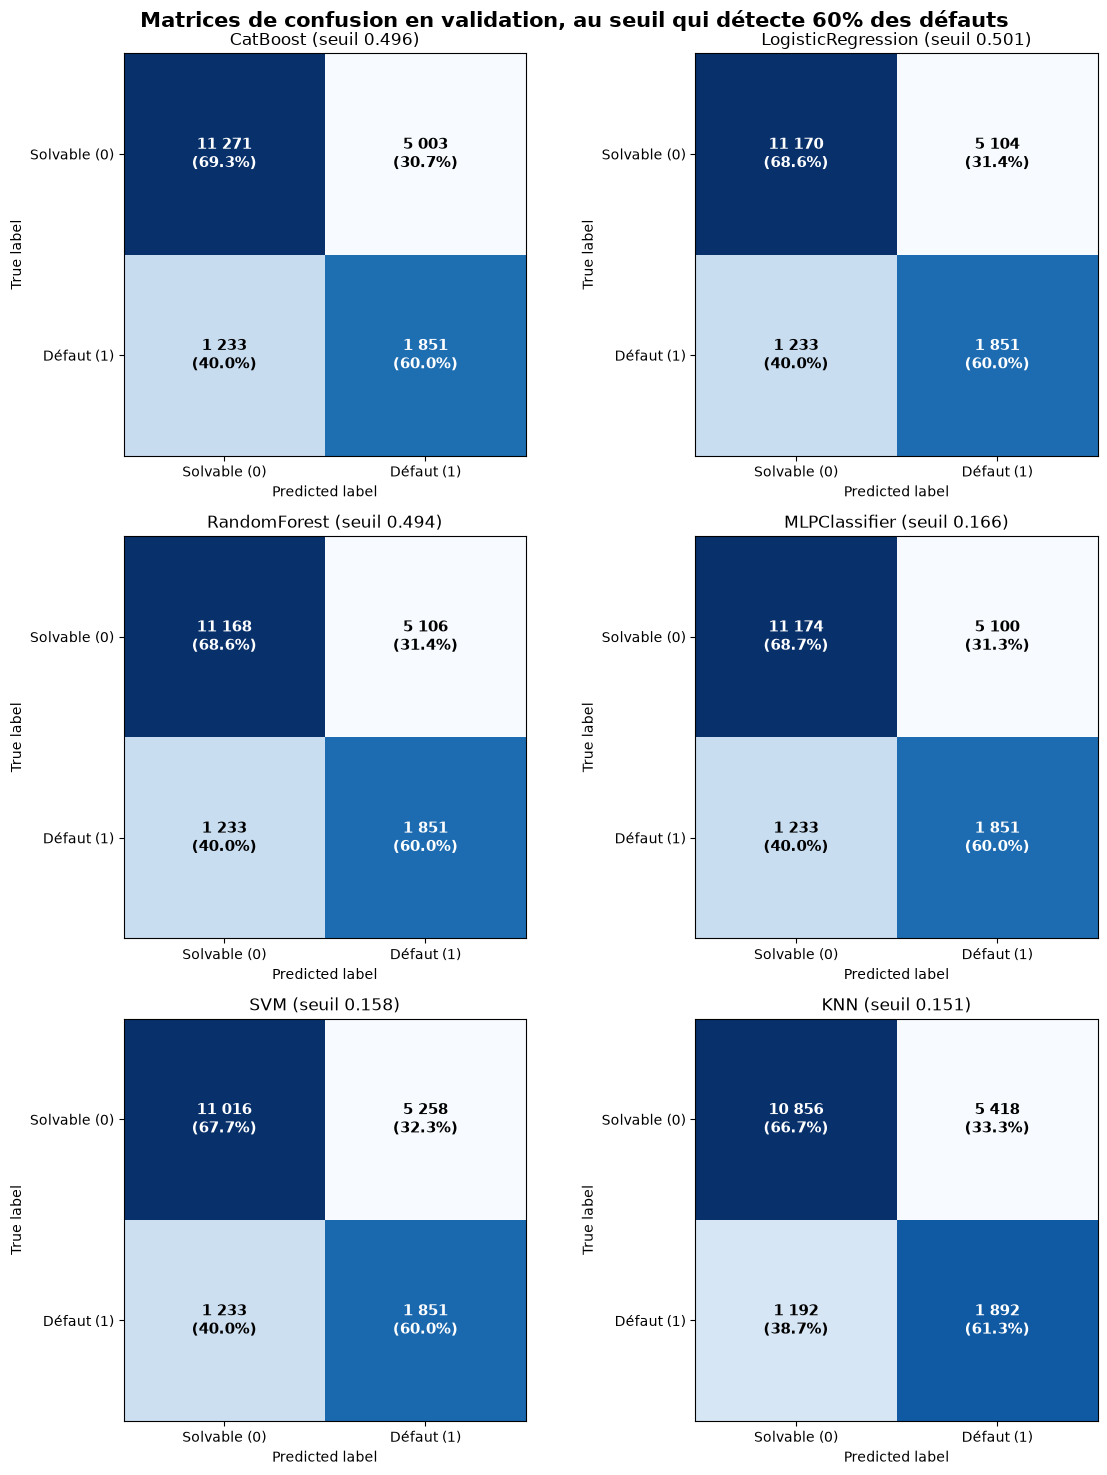

Défauts dans le train : **3084** ; taux de défaut (précision d'un tirage au hasard) : **15.9 %**

**Détection au seuil qui trouve 60% des défauts : effectifs**

,Seuil,Prédits en défaut,Défauts détectés,Fausses alertes,Défauts manqués
Modèle,,,,,
CatBoost,0.496,6854,1851,5003,1233
LogisticRegression,0.501,6955,1851,5104,1233
RandomForest,0.494,6957,1851,5106,1233
MLPClassifier,0.166,6951,1851,5100,1233
SVM,0.158,7109,1851,5258,1233
KNN,0.151,7310,1892,5418,1192


**Détection au seuil qui trouve 60% des défauts : taux**

,Précision (%),Rappel (%),Clients signalés (%)
Modèle,,,
CatBoost,27.0,60.0,35.4
LogisticRegression,26.6,60.0,35.9
RandomForest,26.6,60.0,35.9
MLPClassifier,26.6,60.0,35.9
SVM,26.0,60.0,36.7
KNN,25.9,61.3,37.8


...

,Rappel 44% (1re itération),Rappel 60% (minimal),Rappel 70%,Rappel 80%
Modèle,,,,
CatBoost,34.1,27.0,24.3,22.0
LogisticRegression,31.7,26.6,24.0,21.3
RandomForest,33.4,26.6,23.6,21.2
MLPClassifier,32.3,26.6,24.2,21.7
SVM,32.5,26.0,23.7,21.3
KNN,31.2,25.9,23.4,21.1


**Part des clients signalés (%) selon le rappel**

,Rappel 44% (1re itération),Rappel 60% (minimal),Rappel 70%,Rappel 80%
Modèle,,,,
CatBoost,20.6,35.4,45.9,57.8
LogisticRegression,22.1,35.9,46.5,59.9
RandomForest,21.0,35.9,47.3,60.2
MLPClassifier,21.7,35.9,46.2,58.9
SVM,21.6,36.7,47.1,59.8
KNN,23.0,37.8,48.5,60.9


**Importance des variables (%), à lire colonne par colonne**

,CatBoost,LogisticRegression,RandomForest,MLPClassifier,Moyenne (%)
Variable,,,,,
PAY_2,12.6,0.5,14.8,3.2,7.8
PAY_1,11.9,1.7,13.7,2.8,7.5
LIMIT_BAL,13.1,3.0,6.7,3.1,6.5
PAY_3,7.5,2.1,9.1,2.8,5.4
PAY_AMT1,4.3,4.5,7.1,4.0,5.0
PAY_5,5.5,2.4,6.5,3.2,4.4
PAY_AMT2,5.8,2.7,5.7,3.2,4.4
BILL_AMT1,6.3,4.6,2.0,3.8,4.2
PAY_4,5.6,0.5,7.9,2.7,4.2


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict

ordre = df_final["Modèle"].tolist()
RAPPELS_AFFICHES = [0.44, 0.60, 0.70, 0.80]   # 0,44 : rappel de la première itération sur la population laissée au ML
y = y_train.to_numpy()

# Probabilités hors pli de la version retenue de chaque modèle, enregistrées pour tout calcul ultérieur
probas = {nom: cross_val_predict(best_models[nom], X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1] for nom in ordre}
dossier_probas = root_dir / "data" / "ML" / "probas_hors_pli"
dossier_probas.mkdir(exist_ok=True)
pd.DataFrame({"ID": train["ID"].to_numpy(), "dpnm": y, "version_methode": VERSION_METHODE, **probas}).to_csv(dossier_probas / f"ml_{numero_scenario}_{VERSION_METHODE}.csv", index=False)
print(f"Probabilités hors pli enregistrées : {dossier_probas / f'ml_{numero_scenario}_{VERSION_METHODE}.csv'}\n")

# Matrices de confusion et tableau de détection, au seuil du rappel minimal
nb_lignes = (len(ordre) + 1) // 2
fig, axes = plt.subplots(nb_lignes, 2, figsize=(12, 5 * nb_lignes), squeeze=False)
for ax_vide in axes.flatten()[len(ordre):]:
    ax_vide.axis("off")
fig.suptitle(f"Matrices de confusion en validation, au seuil qui détecte {RAPPEL_MINIMAL:.0%} des défauts", fontsize=15, fontweight="bold")
lignes = []
for k, nom in enumerate(ordre):
    seuil = seuil_pour_rappel(y, probas[nom])
    cm = confusion_matrix(y, probas[nom] >= seuil)
    tn, fp, fn, tp = cm.ravel()
    lignes.append({
        "Modèle": nom, "Seuil": seuil, "Prédits en défaut": tp + fp, "Défauts détectés": tp, "Fausses alertes": fp, "Défauts manqués": fn,
        "Précision (%)": tp / (tp + fp) * 100, "Rappel (%)": tp / (tp + fn) * 100, "Clients signalés (%)": (tp + fp) / len(y) * 100,
    })
    ax = axes.flatten()[k]
    cm_part = cm / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_part, display_labels=["Solvable (0)", "Défaut (1)"]).plot(cmap="Blues", ax=ax, colorbar=False, include_values=False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_part[i, j]:.1%})".replace(",", " "), ha="center", va="center",
                    color="white" if cm_part[i, j] > 0.5 else "black", fontweight="bold", fontsize=11)
    ax.set_title(f"{nom} (seuil {seuil:.3f})")
plt.tight_layout()
plt.show()

df_detection = pd.DataFrame(lignes)
display(Markdown(f"Défauts dans le train : **{y.sum()}** ; taux de défaut (précision d'un tirage au hasard) : **{y.mean() * 100:.1f} %**"))
montrer(df_detection[["Modèle", "Seuil", "Prédits en défaut", "Défauts détectés", "Fausses alertes", "Défauts manqués"]].round(3),
        f"Détection au seuil qui trouve {RAPPEL_MINIMAL:.0%} des défauts : effectifs")
montrer(df_detection[["Modèle", "Précision (%)", "Rappel (%)", "Clients signalés (%)"]].round(1),
        f"Détection au seuil qui trouve {RAPPEL_MINIMAL:.0%} des défauts : taux")

# Précision et part des clients signalés à plusieurs rappels
def nom_rappel(r):
    return f"Rappel {r:.0%}" + (" (1re itération)" if r == 0.44 else " (minimal)" if r == RAPPEL_MINIMAL else "")

precision_rappel, signales_rappel = [], []
for nom in ordre:
    ligne_p, ligne_s = {"Modèle": nom}, {"Modèle": nom}
    for r in RAPPELS_AFFICHES:
        signales = probas[nom] >= seuil_pour_rappel(y, probas[nom], r)
        ligne_p[nom_rappel(r)] = round(y[signales].mean() * 100, 1)
        ligne_s[nom_rappel(r)] = round(signales.mean() * 100, 1)
    precision_rappel.append(ligne_p)
    signales_rappel.append(ligne_s)
montrer(pd.DataFrame(precision_rappel), "Précision (%) selon le rappel : part des clients signalés réellement en défaut")
montrer(pd.DataFrame(signales_rappel), "Part des clients signalés (%) selon le rappel")

# Importance des variables
noms_variables = [n.split("__", 1)[1] for n in best_models[ordre[0]][0].get_feature_names_out()]
importances = {}
for nom in ordre:
    clf = best_models[nom][-1]
    if isinstance(clf, CalibratedClassifierCV):
        clf = clf.calibrated_classifiers_[0].estimator
    if hasattr(clf, "feature_importances_"):
        brut = np.asarray(clf.feature_importances_, dtype=float)
    elif hasattr(clf, "coef_"):
        brut = np.abs(clf.coef_[0])
    elif hasattr(clf, "coefs_"):
        brut = np.abs(clf.coefs_[0]).sum(axis=1)
    else:
        continue
    importances[nom] = brut / brut.sum() * 100
df_importances = pd.DataFrame(importances, index=noms_variables)
df_importances["Moyenne (%)"] = df_importances.mean(axis=1)
montrer(df_importances.sort_values("Moyenne (%)", ascending=False).round(1).reset_index(names="Variable"),
       "Importance des variables (%), à lire colonne par colonne")


**Lecture** : tous les modèles détectent la même part des défauts (le rappel minimal) ; ils se départagent donc par la **précision**, c'est-à-dire par le nombre de fausses alertes qu'ils coûtent pour y arriver. La précision se compare au taux de défaut du train (la précision d'un tirage au hasard). Le tableau à plusieurs rappels montre le prix d'un rappel plus élevé : plus de défauts détectés, mais plus de clients signalés à tort. Les importances ne se comparent qu'à l'intérieur d'une colonne : chaque modèle mesure le poids des variables à sa façon.


## 5. Classement final, podium et enregistrement

**Score de classement final : le « score décisionnel F2 ».** La boucle a choisi les réglages de chaque modèle sur la précision au rappel minimal (ses seuils de surapprentissage, de plancher et d'instabilité sont calibrés sur elle). Pour **classer les modèles entre eux** et **comparer les scénarios**, on calcule ensuite, une seule fois, le F2 de chaque modèle à son point de fonctionnement réel : au seuil qui détecte au moins le rappel minimal, pli par pli, avec son écart-type. Le F2 monte avec la précision et avec le rappel : à rappel égal, la meilleure précision gagne ; à précision égale, le meilleur rappel gagne (cas d'un modèle qui dépasse un peu le rappel minimal, comme le KNN et ses égalités). Il réunit les deux en un score unique. La précision, le rappel réel et les autres métriques restent affichés et enregistrés.

**Le podium** classe les versions retenues par la boucle selon ce F2. La colonne « Écart au premier » est comparée à l'écart-type du F2 du premier : si l'écart est plus petit, le modèle est **à égalité** avec le premier (la différence est dans le bruit de la validation croisée).

Le premier du podium est enregistré dans `lab_ML/best_models/`, **avec son seuil** : la méthode `predict()` d'un modèle coupe toujours à 0,5, alors que le seuil retenu est celui qui atteint le rappel minimal sur les probabilités hors pli du train. Le fichier contient le modèle, son nom, son seuil, le rappel minimal, la liste des variables attendues et le scénario ; pour prédire, on compare `predict_proba(X)[:, 1]` au seuil.


In [9]:
import joblib
from sklearn.metrics import fbeta_score

# Score de classement final : F2 au point de fonctionnement de chaque modèle (seuil du rappel minimal), pli par pli,
# sur les probabilités hors pli (mêmes plis que la boucle)
plis = list(cv.split(X_train, y_train))

def f2_au_rappel_minimal(y_vrai, proba):
    return fbeta_score(y_vrai, proba >= seuil_pour_rappel(y_vrai, proba), beta=2)

f2_plis = {nom: [f2_au_rappel_minimal(y[val], probas[nom][val]) for _, val in plis] for nom in ordre}
df_final["F2 (val)"] = df_final["Modèle"].map({nom: np.mean(v) for nom, v in f2_plis.items()})
df_final["Écart-type F2 (val)"] = df_final["Modèle"].map({nom: np.std(v) for nom, v in f2_plis.items()})
classement = df_final.sort_values("F2 (val)", ascending=False).reset_index(drop=True)
rappel_reel = df_detection.set_index("Modèle")["Rappel (%)"]

premier = classement.iloc[0]
podium = pd.DataFrame({
    "Rang": [["🥇", "🥈", "🥉"][i] if i < 3 else str(i + 1) for i in range(len(classement))],
    "Modèle": classement["Modèle"],
    "Score décisionnel F2": classement["F2 (val)"].round(3),
    "Écart-type F2": classement["Écart-type F2 (val)"].round(3),
    "Écart au premier (F2)": (premier["F2 (val)"] - classement["F2 (val)"]).round(3),
    "À égalité avec le premier": (premier["F2 (val)"] - classement["F2 (val)"] <= premier["Écart-type F2 (val)"]).map({True: "oui", False: "non"}),
    f"{LIBELLE_SCORE} (%)": pct(classement["Précision (val)"]),
    "Rappel réel (%)": classement["Modèle"].map(rappel_reel).round(1),
    "ROC AUC": classement["ROC AUC (val)"].round(3),
    "Alerte": classement["Alerte"],
})
montrer(podium, "Podium des versions retenues, classées par score décisionnel F2 (validation)")

# Enregistrement du meilleur modèle (version retenue par la boucle, entraînée sur tout le train par la GridSearch) avec son seuil :
# predict() du modèle coupe à 0,5 ; pour prédire, comparer predict_proba(X)[:, 1] au seuil enregistré
seuil_premier = float(seuil_pour_rappel(y, probas[premier["Modèle"]]))
dossier_modeles = root_dir / "lab_ML" / "best_models"
dossier_modeles.mkdir(exist_ok=True)
chemin = dossier_modeles / f"model_ml_{numero_scenario}.joblib"
joblib.dump({
    "modele": best_models[premier["Modèle"]],
    "nom": premier["Modèle"],
    "seuil": seuil_premier,               # seuil qui atteint le rappel minimal sur les probabilités hors pli du train
    "rappel_minimal": RAPPEL_MINIMAL,         # rappel minimal
    "variables": variables,               # colonnes attendues, dans cet ordre
    "scenario": f"ml_{numero_scenario}",
}, chemin)
print(f"Modèle enregistré : {chemin}")
print(f"{premier['Modèle']}, seuil {seuil_premier:.3f} (rappel minimal {RAPPEL_MINIMAL:.0%}) ; "
      f"prédire en défaut si predict_proba(X)[:, 1] >= seuil")

**Podium des versions retenues, classées par score décisionnel F2 (validation)**

,Modèle,Score décisionnel F2,Écart-type F2,Écart au premier (F2),À égalité avec le premier,Précision des défauts prédits (%),Rappel réel (%),ROC AUC,Alerte
Rang,,,,,,,,,
🥇,CatBoost,0.483,0.009,0.000,oui,27.1,60.0,0.710,✅ OK
🥈,LogisticRegression,0.482,0.007,0.001,oui,27.0,60.0,0.696,✅ OK
🥉,RandomForest,0.480,0.010,0.003,oui,26.6,60.0,0.700,✅ OK
4,KNN,0.480,0.015,0.004,oui,26.2,61.3,0.699,✅ OK ; ⚠️ INSTABLE
5,MLPClassifier,0.480,0.007,0.004,oui,26.6,60.0,0.698,✅ OK
6,SVM,0.477,0.011,0.006,oui,26.3,60.0,0.699,✅ OK


Modèle enregistré : c:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\lab_ML\best_models\model_ml_7.joblib
CatBoost, seuil 0.496 (rappel minimal 60%) ; prédire en défaut si predict_proba(X)[:, 1] >= seuil


## 6. Résultats enregistrés et ligne du journal

- **Fichier de résultats** `data/ML/resultats_scenarios.csv`, commun à tous les scénarios : une ligne par modèle, avec le scénario, la version de la méthode, la date, la **traçabilité** (commit git du code, marqué « + modifications » si le code n'était pas commité ; empreinte du fichier `train_dataset.csv` ; niveau de nettoyage des données), l'étalon, les variables, les scores (validation, entraînement, écarts), l'alerte, la boucle (tours, arrêt, réglage) et la détection au rappel minimal (seuil, défauts détectés, part des clients signalés). Relancer un scénario remplace ses lignes **pour la même version de la méthode** ; les lignes des versions précédentes sont gardées : elles tracent l'effet de chaque évolution de la méthode. Ce fichier sert aux comparaisons entre scénarios et aux graphiques.
- **Ligne du journal** : la ligne à recopier telle quelle sous la dernière ligne du tableau des scénarios de `tableau_ML.md` ; seule la colonne « Décision » reste à compléter.


In [10]:
import hashlib
import json
import subprocess
from datetime import datetime

# Traçabilité : code (commit git, « + modifications » si le code n'était pas commité), données (empreinte du train, source)
def commit_git():
    try:
        commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True, cwd=root_dir).stdout.strip()
        modifie = subprocess.run(["git", "status", "--porcelain", "--", "lab_ML", "src"], capture_output=True, text=True, cwd=root_dir).stdout.strip()
        return (commit + " + modifications") if modifie else commit
    except Exception:
        return "inconnu"

chemin_train = root_dir / "data" / "ML" / "train_dataset.csv"
empreinte_train = hashlib.sha256(chemin_train.read_bytes()).hexdigest()[:12]
chemin_source = root_dir / "data" / "ML" / "source_datasets.json"
source = json.loads(chemin_source.read_text(encoding="utf-8")) if chemin_source.exists() else {}

# 1) Fichier de résultats commun à tous les scénarios : une ligne par modèle
detection = df_detection.set_index("Modèle")
resultats = pd.DataFrame({
    "scenario": f"ml_{numero_scenario}",
    "version_methode": VERSION_METHODE,
    "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "commit": commit_git(),
    "empreinte_train": empreinte_train,
    "niveau_nettoyage": source.get("niveau_nettoyage", "inconnu"),
    "etalon": f"Classement : score décisionnel F2 ; réglage : précision des défauts prédits (taux de rappel minimal {RAPPEL_MINIMAL:.0%})",
    "rappel_minimal": RAPPEL_MINIMAL,
    "nb_variables": len(variables),
    "variables_ajoutees": ", ".join(ajout_num + ajout_log + ajout_log_signe + ajout_cat + ajout_ord) or "aucune",
    "variables_retirees": ", ".join(retirees) or "aucune",
    "rang": range(1, len(classement) + 1),
    "modele": classement["Modèle"],
    "f2_val": classement["F2 (val)"],
    "ecart_type_f2": classement["Écart-type F2 (val)"],
    "precision_val": classement["Précision (val)"],
    "ecart_type": classement["Écart-type précision (val)"],
    "roc_auc_val": classement["ROC AUC (val)"],
    "precision_moyenne_val": classement["Précision moyenne (val)"],
    "score_train": classement["Précision (train)"],
    "ecart_train_val": classement["Écart train - val"],
    "ecart_relatif": classement["Écart relatif"],
    "alerte": classement["Alerte"],
    "tours": classement["Modèle"].map(df_historique["Modèle"].value_counts()),
    "arret": classement["Arrêt"],
    "reglage": classement["Meilleurs paramètres"].map(parametres),
    "seuil": classement["Modèle"].map(detection["Seuil"]),
    "defauts_detectes": classement["Modèle"].map(detection["Défauts détectés"]),
    "rappel_pct": classement["Modèle"].map(detection["Rappel (%)"]),
    "precision_pct": classement["Modèle"].map(detection["Précision (%)"]),
    "clients_signales_pct": classement["Modèle"].map(detection["Clients signalés (%)"]),
})
chemin_resultats = root_dir / "data" / "ML" / "resultats_scenarios.csv"
if chemin_resultats.exists():
    anciens = pd.read_csv(chemin_resultats)
    meme_lancement = (anciens["scenario"] == f"ml_{numero_scenario}") & (anciens["version_methode"] == VERSION_METHODE)
    resultats = pd.concat([anciens[~meme_lancement], resultats], ignore_index=True)
resultats.to_csv(chemin_resultats, index=False)
print(f"Résultats enregistrés : {chemin_resultats} ({len(resultats)} lignes au total)")

# 2) Ligne du journal (tableau_ML.md), à recopier sous la dernière ligne du tableau des scénarios
def fr(v, decimales=1):
    return f"{v:.{decimales}f}".replace(".", ",")

def entier_fr(v):
    return f"{v:,.0f}".replace(",", " ")

p1 = classement.iloc[0]
d1 = detection.loc[p1["Modèle"]]
egaux = [m for m, s in zip(classement["Modèle"][1:], classement["F2 (val)"][1:]) if p1["F2 (val)"] - s <= p1["Écart-type F2 (val)"]]
ligne_journal = (
    f"| [`ml_{numero_scenario}`](ml_{numero_scenario}.ipynb) | {ce_qui_change} | {len(variables)} "
    f"| Classement : score décisionnel F2 ; réglage : précision des défauts prédits (taux de rappel minimal {RAPPEL_MINIMAL:.0%}, méthode {VERSION_METHODE}) "
    f"| {p1['Modèle']} (écart relatif train - val {fr(p1['Écart relatif'] * 100)} %)"
    + (f", à égalité avec {', '.join(egaux)}" if egaux else "")
    + f" | score décisionnel F2 {fr(p1['F2 (val)'], 3)} ± {fr(p1['Écart-type F2 (val)'], 3)} ; précision {fr(p1['Précision (val)'] * 100)} % ± "
    f"{fr(p1['Écart-type précision (val)'] * 100)} pts ; ROC AUC {fr(p1['ROC AUC (val)'], 3)} "
    f"| {entier_fr(d1['Défauts détectés'])} sur {entier_fr(y.sum())} ({fr(d1['Rappel (%)'])} %) / {fr(d1['Précision (%)'])} %, "
    f"{fr(d1['Clients signalés (%)'])} % des clients signalés | *à compléter* |"
)
display(Markdown("**Ligne à recopier sous la dernière ligne du tableau des scénarios de `tableau_ML.md`** (colonne « Décision » à compléter) :"))
print(ligne_journal)


Résultats enregistrés : c:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\data\ML\resultats_scenarios.csv (72 lignes au total)


**Ligne à recopier sous la dernière ligne du tableau des scénarios de `tableau_ML.md`** (colonne « Décision » à compléter) :

| [`ml_7`](ml_7.ipynb) | ml_4 + ajout des colonnes `ratio_PAY_BILL_regularite` et `TYPE_USAGE` ; 6 modèles | 29 | Classement : score décisionnel F2 ; réglage : précision des défauts prédits (taux de rappel minimal 60%, méthode v8) | CatBoost (écart relatif train - val 4,3 %), à égalité avec LogisticRegression, RandomForest, KNN, MLPClassifier, SVM | score décisionnel F2 0,483 ± 0,009 ; précision 27,1 % ± 1,4 pts ; ROC AUC 0,710 | 1 851 sur 3 084 (60,0 %) / 27,0 %, 35,4 % des clients signalés | *à compléter* |


## 7. Comparaison avec le scénario de référence

Le scénario de référence est choisi à la main dans la cellule 1 (`scenario_reference` : le scénario **retenu** auquel se comparer ; aucun pour le socle). Les deux scénarios ont exactement le même train et les mêmes 5 plis : le score décisionnel F2 se compare donc **pli par pli**. Comparer pli par pli est plus sûr que comparer deux moyennes : on voit si le nouveau scénario gagne sur chaque pli, ou seulement en moyenne.
- **Meilleur contre meilleur** : le premier du podium de chaque scénario.
- **Par modèle** : chaque modèle présent dans les deux scénarios (une nouvelle variable peut aider un modèle et pas un autre).
- **Verdict** : « gain réel » si le gain moyen dépasse l'écart-type des gains sur les 5 plis ; « perte » s'il est en dessous de moins cet écart-type ; sinon « dans le bruit ».

**Les données viennent uniquement des fichiers enregistrés** : les probabilités hors pli de chaque scénario (`ml_<scénario>_<version>.csv`) et le fichier de résultats (podium, rappel minimal). Aucun modèle n'est réentraîné et aucune prédiction n'est refaite. La cellule est autonome : après une réinitialisation du noyau, il suffit d'exécuter la cellule 1 puis celle-ci. Les deux scénarios doivent avoir été lancés avec la même version de la méthode et le même rappel minimal ; sinon, la comparaison est refusée. Après un clone du dépôt, ces fichiers n'existent pas : il faut d'abord relancer les scénarios comparés (section 0 de `methodologie_ML.md`).


In [11]:
# Comparaison entre scénarios, à partir des seuls fichiers enregistrés (probabilités hors pli et fichier de résultats).
# Cellule autonome : ses imports et ses fonctions sont ici ; elle fonctionne après une réinitialisation du noyau (cellule 1 exécutée).
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import Markdown, display
from sklearn.metrics import fbeta_score
from sklearn.model_selection import StratifiedKFold

dossier_ml = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "data").exists()) / "data" / "ML"

def seuil_rappel_minimal(y_vrai, proba, rappel):
    # Seuil le plus haut qui détecte au moins la part voulue des défauts
    proba_defauts = np.sort(proba[y_vrai == 1])[::-1]
    return proba_defauts[int(np.ceil(rappel * len(proba_defauts))) - 1]

def f2_final(y_vrai, proba, rappel):
    return fbeta_score(y_vrai, proba >= seuil_rappel_minimal(y_vrai, proba, rappel), beta=2)

def lire_scenario(scenario, version):
    # Probabilités hors pli et lignes du fichier de résultats d'un scénario, pour une version de la méthode ; (None, None) si absent
    chemin = dossier_ml / "probas_hors_pli" / f"ml_{scenario}_{version}.csv"
    resultats = pd.read_csv(dossier_ml / "resultats_scenarios.csv")
    lignes = resultats[(resultats["scenario"] == f"ml_{scenario}") & (resultats["version_methode"] == version)]
    if not chemin.exists() or lignes.empty:
        return None, None
    return pd.read_csv(chemin), lignes

def comparer_scenarios(scenario, reference, version):
    """Compare ml_<scenario> à ml_<reference> : score décisionnel F2 pli par pli, pour le meilleur modèle de chaque scénario et pour chaque modèle commun."""
    actuel, lignes_actuel = lire_scenario(scenario, version)
    ref, lignes_ref = lire_scenario(reference, version)
    for nom, donnees in ((scenario, actuel), (reference, ref)):
        if donnees is None:
            display(Markdown(f"⚠️ **Comparaison impossible** : `ml_{nom}` n'a pas de résultats enregistrés avec la méthode {version}. "
                             f"Lancer (ou relancer) d'abord `ml_{nom}` avec cette méthode."))
            return None
    rappel, rappel_ref = lignes_actuel["rappel_minimal"].iloc[0], lignes_ref["rappel_minimal"].iloc[0]
    if rappel != rappel_ref:
        display(Markdown(f"⚠️ **Comparaison refusée** : rappels minimaux différents ({rappel:.0%} et {rappel_ref:.0%})."))
        return None
    if len(actuel) != len(ref) or not (actuel["ID"].to_numpy() == ref["ID"].to_numpy()).all():
        display(Markdown("⚠️ **Comparaison impossible** : les deux scénarios n'ont pas le même train."))
        return None
    y_vrai = actuel["dpnm"].to_numpy()
    # Mêmes plis que la boucle : StratifiedKFold à 5 plis, graine 42 (ils ne dépendent que de la cible et de l'ordre des clients)
    plis = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(np.zeros(len(y_vrai)), y_vrai))

    def comparer(libelle, proba_ref, proba_actuel):
        f2_ref = np.array([f2_final(y_vrai[val], proba_ref[val], rappel) for _, val in plis])
        f2_actuel = np.array([f2_final(y_vrai[val], proba_actuel[val], rappel) for _, val in plis])
        gains = f2_actuel - f2_ref
        if gains.mean() > gains.std():
            verdict = "✅ gain réel"
        elif gains.mean() < -gains.std():
            verdict = "❌ perte"
        else:
            verdict = "➖ dans le bruit"
        return {"Comparaison": libelle, "Score décisionnel F2 (référence)": round(f2_ref.mean(), 3), "Score décisionnel F2 (comparé)": round(f2_actuel.mean(), 3),
                "Gain moyen": round(gains.mean(), 3), "Écart-type des gains (plis)": round(gains.std(), 3),
                "Plis gagnés": f"{(gains > 0).sum()} sur {len(plis)}", "Verdict": verdict}

    meilleur_ref = lignes_ref.loc[lignes_ref["rang"] == 1, "modele"].iloc[0]
    meilleur_actuel = lignes_actuel.loc[lignes_actuel["rang"] == 1, "modele"].iloc[0]
    lignes = [comparer(f"Meilleur contre meilleur ({meilleur_ref} → {meilleur_actuel})", ref[meilleur_ref].to_numpy(), actuel[meilleur_actuel].to_numpy())]
    lignes += [comparer(nom, ref[nom].to_numpy(), actuel[nom].to_numpy())
               for nom in lignes_actuel.sort_values("rang")["modele"] if nom in ref.columns]
    df = pd.DataFrame(lignes)
    display(Markdown(f"**Comparaison de `ml_{scenario}` avec `ml_{reference}` : score décisionnel F2 pli par pli (méthode {version})**"))
    display(df.set_index("Comparaison"))
    return df

# Comparaison standard : avec le scénario de référence choisi dans la cellule 1
if scenario_reference is None:
    display(Markdown("Pas de scénario de référence : ce scénario est le socle."))
else:
    comparer_scenarios(numero_scenario, scenario_reference, VERSION_METHODE)


**Comparaison de `ml_7` avec `ml_4` : score décisionnel F2 pli par pli (méthode v8)**

,Score décisionnel F2 (référence),Score décisionnel F2 (comparé),Gain moyen,Écart-type des gains (plis),Plis gagnés,Verdict
Comparaison,,,,,,
Meilleur contre meilleur (CatBoost → CatBoost),0.484,0.483,-0.001,0.003,2 sur 5,➖ dans le bruit
CatBoost,0.484,0.483,-0.001,0.003,2 sur 5,➖ dans le bruit
LogisticRegression,0.482,0.482,0.000,0.004,2 sur 5,➖ dans le bruit
RandomForest,0.480,0.480,0.001,0.002,4 sur 5,➖ dans le bruit
KNN,0.482,0.480,-0.003,0.002,1 sur 5,❌ perte
MLPClassifier,0.476,0.480,0.004,0.005,4 sur 5,➖ dans le bruit
SVM,0.478,0.477,-0.000,0.001,2 sur 5,➖ dans le bruit


## 8. Comparaisons libres

Pour comparer d'autres scénarios que la référence de la cellule 1 : un scénario issu de la **fusion** de deux autres, comparé à chacun d'eux ; un **contrôle** par rapport au socle `ml_0` ; ou deux scénarios quelconques, sans lien avec celui-ci. Même calcul et même verdict qu'en section 7, à partir des seuls fichiers enregistrés.

**Cette cellule se relance seule**, autant de fois que voulu, sans relancer le notebook ni réentraîner de modèle. Après une réinitialisation du noyau : exécuter la cellule 1, puis la cellule de la section 7 (elle définit la fonction de comparaison), puis celle-ci.


In [12]:
# Couples (scénario comparé, scénario de référence), avec la même version de la méthode. Exemples :
#   [("4", "2"), ("4", "3")] : ml_4, fusion de ml_2 et ml_3, comparé à chacun des deux
#   [("4", "0")]             : contrôle de ml_4 par rapport au socle
comparaisons_libres = []
for scenario_compare, scenario_ref in comparaisons_libres:
    comparer_scenarios(scenario_compare, scenario_ref, VERSION_METHODE)
if not comparaisons_libres:
    display(Markdown("Aucune comparaison libre demandée (liste `comparaisons_libres` vide)."))


Aucune comparaison libre demandée (liste `comparaisons_libres` vide).

## Conclusion (socle figé en méthode v8, 05/10/2026)

**Une méthode fiable, rigoureuse et reproductible, qui met tous les modèles en pleine possession de leurs moyens, sans en désavantager un seul.**

- **Le meilleur modèle n'a pas progressé, il est devenu crédible** : CatBoost garde, de la v0 à la v8, la même précision des défauts prédits (environ 27 % au taux de rappel minimal de 60 %) et le même ROC AUC (environ 0,71), mais sans surapprentissage depuis la v4.
- **Les autres modèles l'ont rejoint** : jugés au même taux de rappel minimal (v2), puis nourris de variables mises en forme (codifications traitées comme des nombres en v6, paiements au logarithme en v7, factures au logarithme signé en v8), ils sont tous à égalité avec le premier. La régression logistique, la plus simple et la plus explicable, fait jeu égal avec CatBoost.
- **Le socle a donné ce que ses 23 variables permettent** : le meilleur score ne bouge plus depuis la v4. Pour monter plus haut, il faut de nouvelles informations : c'est le rôle des scénarios `ml_1`, `ml_2`…, construits à partir de ce notebook (copie, puis cellule 1 et cellule « variables du scénario »).

Le détail des versions et de leur effet mesuré est dans `methodologie_ML.md` (section 11) ; les résultats, dans `tableau_ML.md`.
